In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))

Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12
Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


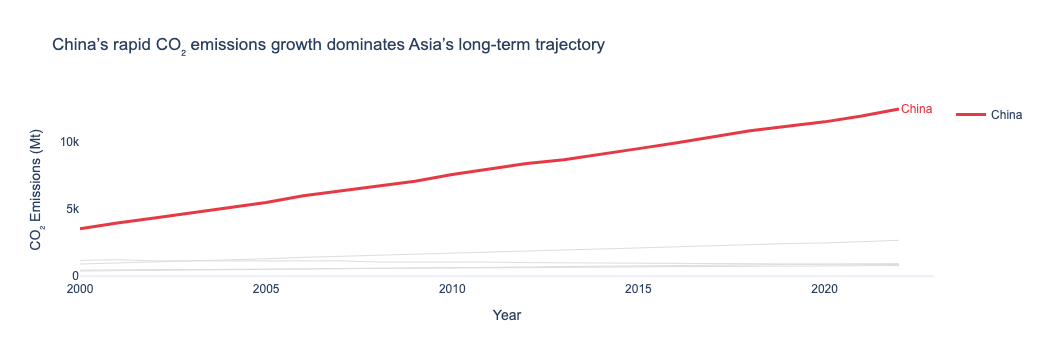

In [3]:
asia = df[df['Region'] == 'Asia']

highlight_country = "China"
countries = asia['Country'].unique()

fig = go.Figure()

for country in countries:
    country_df = asia[asia['Country'] == country].sort_values('Year')
    
    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(color='#E63946', width=3),
            name=country
        ))
        
        fig.add_annotation(
            x=country_df['Year'].max(),
            y=country_df['CO2_Mt'].iloc[-1],
            text="China",
            showarrow=False,
            xanchor='left',
            font=dict(color='#E63946', size=12)
        )
    else:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(color='#DDDDDD', width=1),
            hoverinfo='skip',
            showlegend=False
        ))

fig.update_layout(
    title="China’s rapid CO₂ emissions growth dominates Asia’s long-term trajectory",
    xaxis_title="Year",
    yaxis_title="CO₂ Emissions (Mt)",
    template="plotly_white",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial")
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

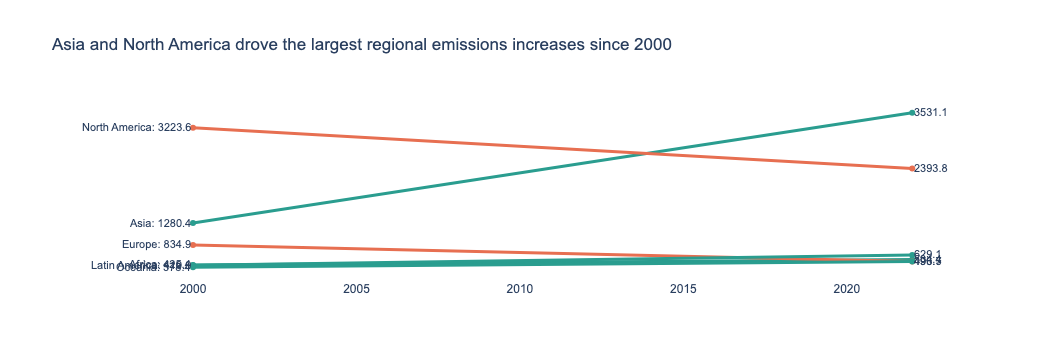

In [5]:
# Task 2 — Slopegraph: regional averages

region_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
slope = region_avg[region_avg['Year'].isin([2000, 2022])]

regions = slope['Region'].unique()

fig = go.Figure()

for region in regions:
    region_data = slope[slope['Region'] == region].sort_values('Year')
    
    y_2000 = region_data[region_data['Year'] == 2000]['CO2_Mt'].values[0]
    y_2022 = region_data[region_data['Year'] == 2022]['CO2_Mt'].values[0]
    
    color = "#2A9D8F" if y_2022 > y_2000 else "#E76F51"
    
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y_2000, y_2022],
        mode='lines+markers',
        line=dict(color=color, width=3),
        showlegend=False
    ))
    
    # Left label (2000)
    fig.add_annotation(
        x=2000,
        y=y_2000,
        text=f"{region}: {y_2000:.1f}",
        showarrow=False,
        xanchor='right',
        font=dict(size=11)
    )
    
    # Right label (2022)
    fig.add_annotation(
        x=2022,
        y=y_2022,
        text=f"{y_2022:.1f}",
        showarrow=False,
        xanchor='left',
        font=dict(size=11)
    )

fig.update_layout(
    title="Asia and North America drove the largest regional emissions increases since 2000",
    template="plotly_white",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial"),
    showlegend=False
)

fig.update_yaxes(showticklabels=False, showgrid=False)
fig.update_xaxes(showgrid=False)

fig.show()